<a href="https://colab.research.google.com/github/Srujan4812/ML_LAB/blob/main/week_6_1BM23CS340.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
pip install tabula-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 88.3 MB/s eta 0:00:00


In [ ]:
import tabula

# Extract data from 'iris (1).pdf'
iris_tables = tabula.read_pdf('/content/iris (1).pdf', pages='all', multiple_tables=True)
if len(iris_tables) > 0:
    iris_df = iris_tables[0] # Assuming the first table is the main one
    print("Iris Data (first 5 rows):")
    print(iris_df.head())
    print("Iris Data Columns:", iris_df.columns.tolist())
else:
    print("No tables found in iris (1).pdf")

print("\n" + "-"*30 + "\n")

# Extract data from 'drug.pdf'
drug_tables = tabula.read_pdf('/content/drug.pdf', pages='all', multiple_tables=True)
if len(drug_tables) > 0:
    drug_df = drug_tables[0] # Assuming the first table is the main one
    print("Drug Data (first 5 rows):")
    print(drug_df.head())
    print("Drug Data Columns:", drug_df.columns.tolist())
else:
    print("No tables found in drug.pdf")

print("\n" + "-"*30 + "\n")

# Extract data from 'petrol_consumption.pdf'
petrol_tables = tabula.read_pdf('/content/petrol_consumption.pdf', pages='all', multiple_tables=True)
if len(petrol_tables) > 0:
    petrol_df = petrol_tables[0] # Assuming the first table is the main one
    print("Petrol Consumption Data (first 5 rows):")
    print(petrol_df.head())
    print("Petrol Consumption Data Columns:", petrol_df.columns.tolist())
else:
    print("No tables found in petrol_consumption.pdf")

Iris Data (first 5 rows):
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
Iris Data Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

------------------------------

Drug Data (first 5 rows):
   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY
Drug Data Columns: ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug']

------------------------------

Petrol Consumption 

In [ ]:
print("Original Petrol Consumption Data Columns:", petrol_df.columns.tolist())

# The column name 'rP_elictreonl_cCe(o%ns)ump' is malformed, likely intended to be 'Petrol_Consumption'
# Rename the column for clarity and usability
petrol_df = petrol_df.rename(columns={'rP_elictreonl_cCe(o%ns)ump': 'Petrol_Consumption'})

print("Revised Petrol Consumption Data Columns:", petrol_df.columns.tolist())
print("Petrol Consumption Data (first 5 rows with updated column name):")
print(petrol_df.head())

Original Petrol Consumption Data Columns: ['Petrol_tax', 'Average_incom', 'Paved_Highway', 'Population_Driv', 'rP_elictreonl_cCe(o%ns)ump']
Revised Petrol Consumption Data Columns: ['Petrol_tax', 'Average_incom', 'Paved_Highway', 'Population_Driv', 'Petrol_Consumption']
Petrol Consumption Data (first 5 rows with updated column name):
   Petrol_tax  Average_incom  Paved_Highway  Population_Driv  \
0         9.0           3571           1976            0.525   
1         9.0           4092           1250            0.572   
2         9.0           3865           1586            0.580   
3         7.5           4870           2351            0.529   
4         8.0           4399            431            0.544   

   Petrol_Consumption  
0                 541  
1                 524  
2                 561  
3                 414  
4                 410  


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# --- Preprocessing iris_df ---
print("\n--- Iris DataFrame Preprocessing ---")
print("Iris DataFrame Info:")
iris_df.info()
print("\nMissing values in Iris DataFrame:\n", iris_df.isnull().sum())

# Separate features and target for iris_df
X_iris = iris_df.drop('species', axis=1)
y_iris = iris_df['species']

# Encode target variable for iris_df
le_iris = LabelEncoder()
y_iris_encoded = le_iris.fit_transform(y_iris)
print("\nIris species encoded classes:", le_iris.classes_)

# Split Iris data into training and testing sets
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris_encoded, test_size=0.3, random_state=42)
print(f"\nIris Training Features Shape: {X_train_iris.shape}")
print(f"Iris Testing Features Shape: {X_test_iris.shape}")
print(f"Iris Training Target Shape: {y_train_iris.shape}")
print(f"Iris Testing Target Shape: {y_test_iris.shape}")

# --- Preprocessing drug_df ---
print("\n--- Drug DataFrame Preprocessing ---")
print("Drug DataFrame Info:")
drug_df.info()
print("\nMissing values in Drug DataFrame:\n", drug_df.isnull().sum())

# Separate features and target for drug_df
X_drug = drug_df.drop('Drug', axis=1)
y_drug = drug_df['Drug']

# Encode target variable for drug_df
le_drug = LabelEncoder()
y_drug_encoded = le_drug.fit_transform(y_drug)
print("\nDrug classes encoded:", le_drug.classes_)

# Identify categorical feature columns for one-hot encoding
categorical_features_drug = ['Sex', 'BP', 'Cholesterol']

# Apply OneHotEncoder to categorical features
one_hot_encoder_drug = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preprocessor_drug = ColumnTransformer(
    transformers=[
        ('cat', one_hot_encoder_drug, categorical_features_drug)
    ],
    remainder='passthrough'
)

X_drug_processed = preprocessor_drug.fit_transform(X_drug)

# Get feature names for processed drug data

numerical_features_drug = X_drug.drop(columns=categorical_features_drug).columns
all_feature_names_drug = list(feature_names_drug_ohe) + list(numerical_features_drug)

X_drug_processed_df = pd.DataFrame(X_drug_processed, columns=all_feature_names_drug)
print("\nProcessed Drug Features (first 5 rows):\n", X_drug_processed_df.head())

# Split Drug data into training and testing sets
X_train_drug, X_test_drug, y_train_drug, y_test_drug = train_test_split(X_drug_processed, y_drug_encoded, test_size=0.3, random_state=42)
print(f"\nDrug Training Features Shape: {X_train_drug.shape}")
print(f"Drug Testing Features Shape: {X_test_drug.shape}")
print(f"Drug Training Target Shape: {y_train_drug.shape}")
print(f"Drug Testing Target Shape: {y_test_drug.shape}")

# --- Preprocessing petrol_df ---
print("\n--- Petrol Consumption DataFrame Preprocessing ---")
print("Petrol Consumption DataFrame Info:")
petrol_df.info()
print("\nMissing values in Petrol Consumption DataFrame:\n", petrol_df.isnull().sum())

# Ensure all columns are numeric, convert if necessary (e.g., if tabula extracted as object)
for col in petrol_df.columns:
    if petrol_df[col].dtype == 'object':
        try:
            petrol_df[col] = pd.to_numeric(petrol_df[col].str.replace(',', '')) # Handle commas if present
        except ValueError:
            print(f"Warning: Column '{col}' could not be converted to numeric.")

# Separate features and target for petrol_df
X_petrol = petrol_df.drop('Petrol_Consumption', axis=1)
y_petrol = petrol_df['Petrol_Consumption']

# Split Petrol data into training and testing sets
X_train_petrol, X_test_petrol, y_train_petrol, y_test_petrol = train_test_split(X_petrol, y_petrol, test_size=0.3, random_state=42)
print(f"\nPetrol Training Features Shape: {X_train_petrol.shape}")
print(f"Petrol Testing Features Shape: {X_test_petrol.shape}")
print(f"Petrol Training Target Shape: {y_train_petrol.shape}")
print(f"Petrol Testing Target Shape: {y_test_petrol.shape}")


--- Iris DataFrame Preprocessing ---
Iris DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  45 non-null     float64
 1   sepal_width   45 non-null     float64
 2   petal_length  45 non-null     float64
 3   petal_width   45 non-null     float64
 4   species       45 non-null     object 
dtypes: float64(4), object(1)
memory usage: 1.9+ KB

Missing values in Iris DataFrame:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Iris species encoded classes: ['Iris-setosa']

Iris Training Features Shape: (31, 4)
Iris Testing Features Shape: (14, 4)
Iris Training Target Shape: (31,)
Iris Testing Target Shape: (14,)

--- Drug DataFrame Preprocessing ---
Drug DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 column

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# --- Preprocessing iris_df ---
print("\n--- Iris DataFrame Preprocessing ---")
print("Iris DataFrame Info:")
iris_df.info()
print("\nMissing values in Iris DataFrame:\n", iris_df.isnull().sum())

# Separate features and target for iris_df
X_iris = iris_df.drop('species', axis=1)
y_iris = iris_df['species']

# Encode target variable for iris_df
le_iris = LabelEncoder()
y_iris_encoded = le_iris.fit_transform(y_iris)
print("\nIris species encoded classes:", le_iris.classes_)

# Split Iris data into training and testing sets
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris_encoded, test_size=0.3, random_state=42)
print(f"\nIris Training Features Shape: {X_train_iris.shape}")
print(f"Iris Testing Features Shape: {X_test_iris.shape}")
print(f"Iris Training Target Shape: {y_train_iris.shape}")
print(f"Iris Testing Target Shape: {y_test_iris.shape}")

# --- Preprocessing drug_df ---
print("\n--- Drug DataFrame Preprocessing ---")
print("Drug DataFrame Info:")
drug_df.info()
print("\nMissing values in Drug DataFrame:\n", drug_df.isnull().sum())

# Separate features and target for drug_df
X_drug = drug_df.drop('Drug', axis=1)
y_drug = drug_df['Drug']

# Encode target variable for drug_df
le_drug = LabelEncoder()
y_drug_encoded = le_drug.fit_transform(y_drug)
print("\nDrug classes encoded:", le_drug.classes_)

# Identify categorical feature columns for one-hot encoding
categorical_features_drug = ['Sex', 'BP', 'Cholesterol']

# Apply OneHotEncoder to categorical features using ColumnTransformer
# The OneHotEncoder instance itself is not fitted directly here.
one_hot_encoder_drug_initial = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preprocessor_drug = ColumnTransformer(
    transformers=[
        ('cat', one_hot_encoder_drug_initial, categorical_features_drug)
    ],
    remainder='passthrough'
)

X_drug_processed = preprocessor_drug.fit_transform(X_drug)

# Get the *fitted* one-hot encoder from the preprocessor
fitted_one_hot_encoder_drug = preprocessor_drug.named_transformers_['cat']

# Now get feature names for processed drug data from the fitted encoder
feature_names_drug_ohe = fitted_one_hot_encoder_drug.get_feature_names_out(categorical_features_drug)
numerical_features_drug = X_drug.drop(columns=categorical_features_drug).columns
all_feature_names_drug = list(feature_names_drug_ohe) + list(numerical_features_drug)

X_drug_processed_df = pd.DataFrame(X_drug_processed, columns=all_feature_names_drug)
print("\nProcessed Drug Features (first 5 rows):\n", X_drug_processed_df.head())

# Split Drug data into training and testing sets
X_train_drug, X_test_drug, y_train_drug, y_test_drug = train_test_split(X_drug_processed, y_drug_encoded, test_size=0.3, random_state=42)
print(f"\nDrug Training Features Shape: {X_train_drug.shape}")
print(f"Drug Testing Features Shape: {X_test_drug.shape}")
print(f"Drug Training Target Shape: {y_train_drug.shape}")
print(f"Drug Testing Target Shape: {y_test_drug.shape}")

# --- Preprocessing petrol_df ---
print("\n--- Petrol Consumption DataFrame Preprocessing ---")
print("Petrol Consumption DataFrame Info:")
petrol_df.info()
print("\nMissing values in Petrol Consumption DataFrame:\n", petrol_df.isnull().sum())

# Ensure all columns are numeric, convert if necessary (e.g., if tabula extracted as object)
for col in petrol_df.columns:
    if petrol_df[col].dtype == 'object':
        try:
            petrol_df[col] = pd.to_numeric(petrol_df[col].str.replace(',', '')) # Handle commas if present
        except ValueError:
            print(f"Warning: Column '{col}' could not be converted to numeric.")

# Separate features and target for petrol_df
X_petrol = petrol_df.drop('Petrol_Consumption', axis=1)
y_petrol = petrol_df['Petrol_Consumption']

# Split Petrol data into training and testing sets
X_train_petrol, X_test_petrol, y_train_petrol, y_test_petrol = train_test_split(X_petrol, y_petrol, test_size=0.3, random_state=42)
print(f"\nPetrol Training Features Shape: {X_train_petrol.shape}")
print(f"Petrol Testing Features Shape: {X_test_petrol.shape}")
print(f"Petrol Training Target Shape: {y_train_petrol.shape}")
print(f"Petrol Testing Target Shape: {y_test_petrol.shape}")


--- Iris DataFrame Preprocessing ---
Iris DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  45 non-null     float64
 1   sepal_width   45 non-null     float64
 2   petal_length  45 non-null     float64
 3   petal_width   45 non-null     float64
 4   species       45 non-null     object 
dtypes: float64(4), object(1)
memory usage: 1.9+ KB

Missing values in Iris DataFrame:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Iris species encoded classes: ['Iris-setosa']

Iris Training Features Shape: (31, 4)
Iris Testing Features Shape: (14, 4)
Iris Training Target Shape: (31,)
Iris Testing Target Shape: (14,)

--- Drug DataFrame Preprocessing ---
Drug DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 column

In [ ]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score

# --- Iris Dataset: Decision Tree Classifier ---
print("\n--- Iris Dataset Model Evaluation ---")
# Initialize Decision Tree Classifier
dt_iris = DecisionTreeClassifier(random_state=42)

# Train the model
dt_iris.fit(X_train_iris, y_train_iris)

# Make predictions on the test set
y_pred_iris = dt_iris.predict(X_test_iris)

# Evaluate the model
accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)
precision_iris = precision_score(y_test_iris, y_pred_iris, average='weighted', zero_division=0)
recall_iris = recall_score(y_test_iris, y_pred_iris, average='weighted', zero_division=0)
f1_iris = f1_score(y_test_iris, y_pred_iris, average='weighted', zero_division=0)

print(f"Iris Model Accuracy: {accuracy_iris:.4f}")
print(f"Iris Model Precision: {precision_iris:.4f}")
print(f"Iris Model Recall: {recall_iris:.4f}")
print(f"Iris Model F1-Score: {f1_iris:.4f}")

# --- Drug Dataset: Decision Tree Classifier ---
print("\n--- Drug Dataset Model Evaluation ---")
# Initialize Decision Tree Classifier
dt_drug = DecisionTreeClassifier(random_state=42)

# Train the model
dt_drug.fit(X_train_drug, y_train_drug)

# Make predictions on the test set
y_pred_drug = dt_drug.predict(X_test_drug)

# Evaluate the model
accuracy_drug = accuracy_score(y_test_drug, y_pred_drug)
precision_drug = precision_score(y_test_drug, y_pred_drug, average='weighted', zero_division=0) # Use weighted for multi-class
recall_drug = recall_score(y_test_drug, y_pred_drug, average='weighted', zero_division=0)     # Use weighted for multi-class
f1_drug = f1_score(y_test_drug, y_pred_drug, average='weighted', zero_division=0)           # Use weighted for multi-class

print(f"Drug Model Accuracy: {accuracy_drug:.4f}")
print(f"Drug Model Precision: {precision_drug:.4f}")
print(f"Drug Model Recall: {recall_drug:.4f}")
print(f"Drug Model F1-Score: {f1_drug:.4f}")

# --- Petrol Consumption Dataset: Decision Tree Regressor ---
print("\n--- Petrol Consumption Dataset Model Evaluation ---")
# Initialize Decision Tree Regressor
dt_petrol = DecisionTreeRegressor(random_state=42)

# Train the model
dt_petrol.fit(X_train_petrol, y_train_petrol)

# Make predictions on the test set
y_pred_petrol = dt_petrol.predict(X_test_petrol)

# Evaluate the model
mse_petrol = mean_squared_error(y_test_petrol, y_pred_petrol)
r2_petrol = r2_score(y_test_petrol, y_pred_petrol)

print(f"Petrol Model Mean Squared Error (MSE): {mse_petrol:.4f}")
print(f"Petrol Model R-squared: {r2_petrol:.4f}")


--- Iris Dataset Model Evaluation ---
Iris Model Accuracy: 1.0000
Iris Model Precision: 1.0000
Iris Model Recall: 1.0000
Iris Model F1-Score: 1.0000

--- Drug Dataset Model Evaluation ---
Drug Model Accuracy: 0.9286
Drug Model Precision: 0.9286
Drug Model Recall: 0.9286
Drug Model F1-Score: 0.9286

--- Petrol Consumption Dataset Model Evaluation ---
Petrol Model Mean Squared Error (MSE): 11479.2143
Petrol Model R-squared: 0.4843



--- Visualizing Iris Decision Tree ---


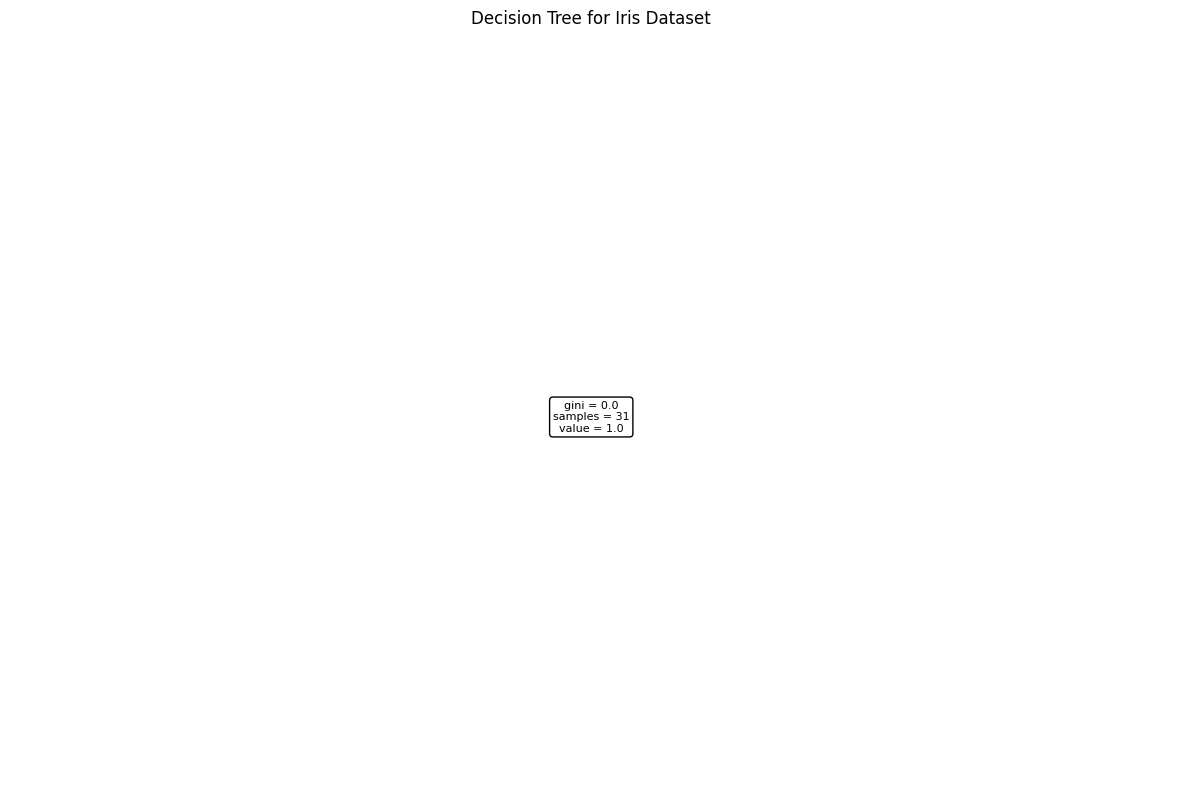


--- Visualizing Drug Decision Tree ---


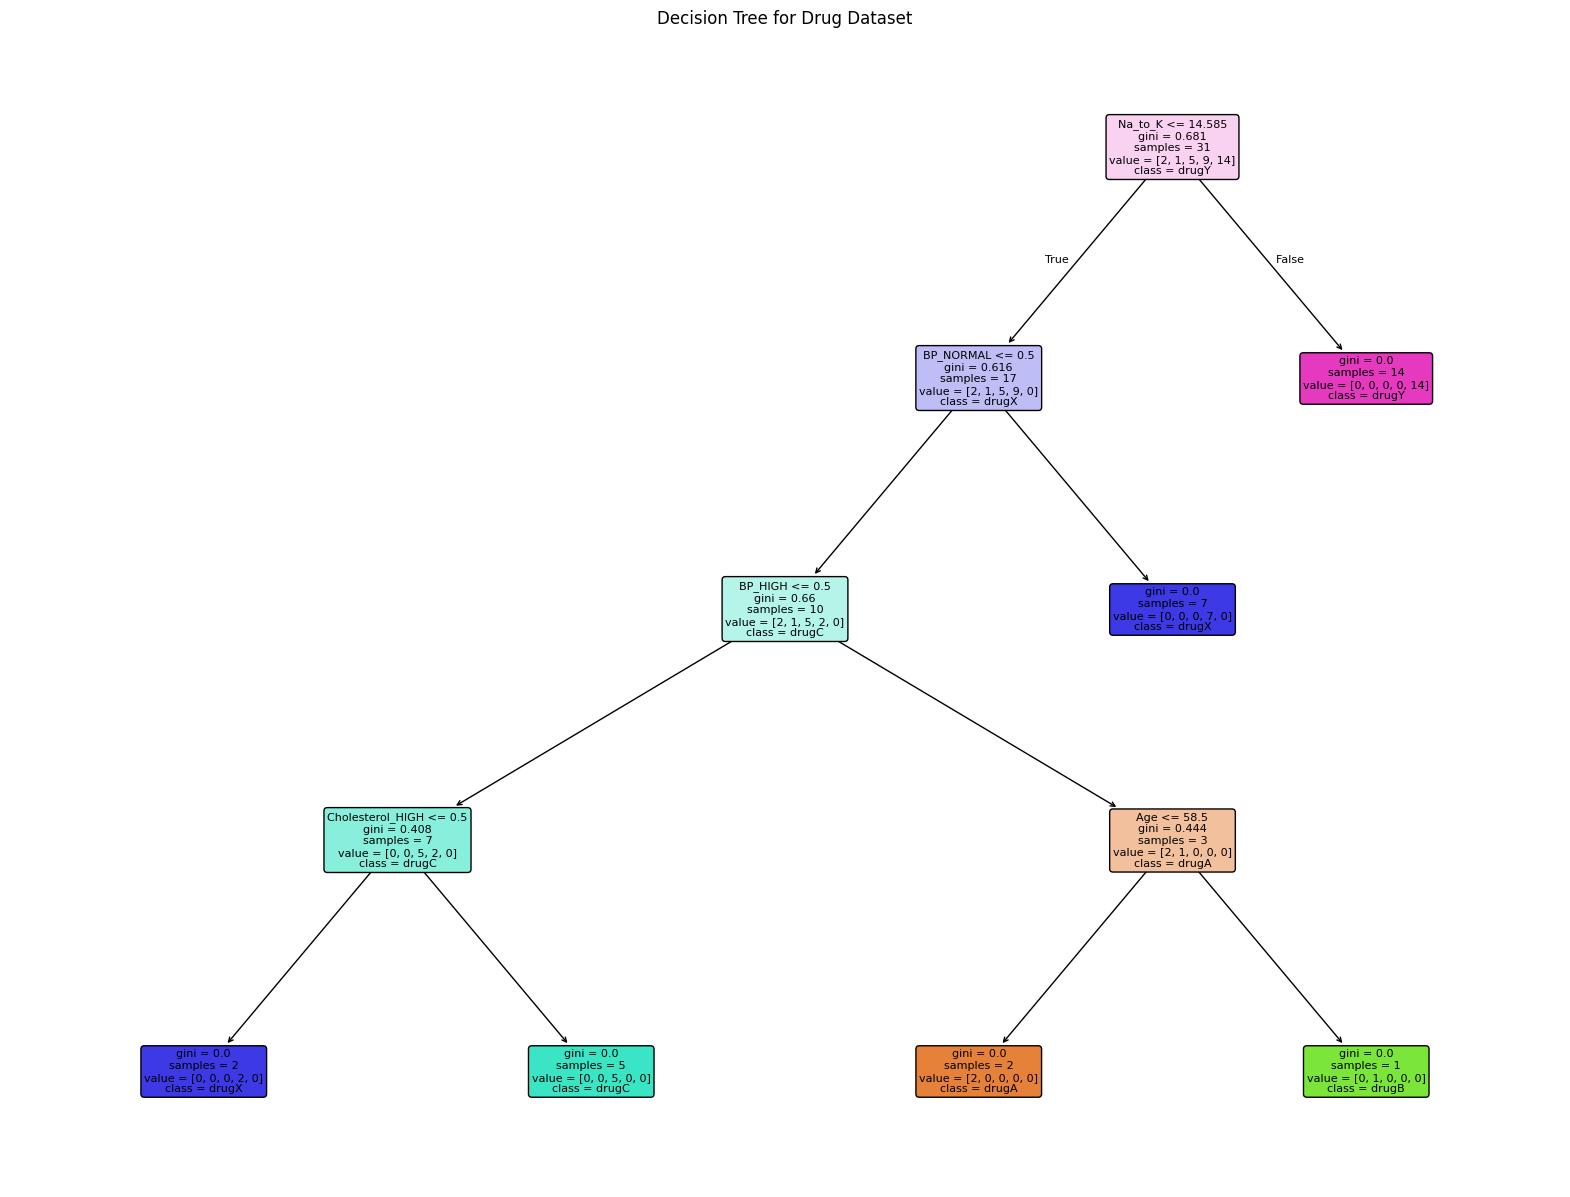


--- Visualizing Petrol Consumption Decision Tree ---


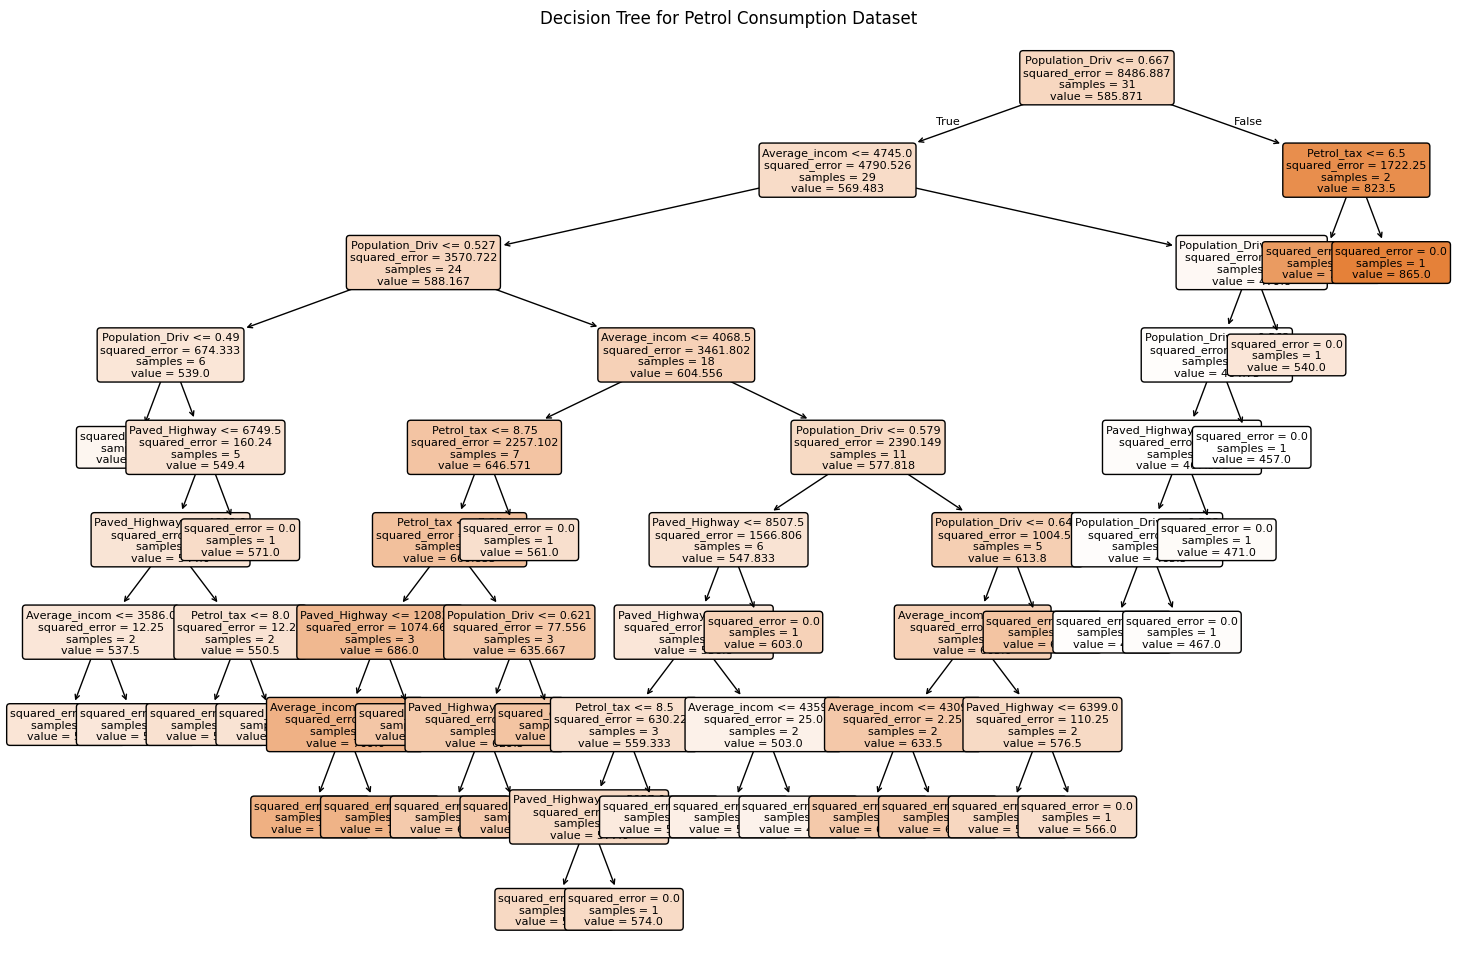


--- Feature Importances ---

Iris Dataset Feature Importances:
sepal_length    0.0
sepal_width     0.0
petal_length    0.0
petal_width     0.0
dtype: float64

Drug Dataset Feature Importances:
Na_to_K               0.503688
BP_NORMAL             0.183468
Cholesterol_HIGH      0.135430
BP_HIGH               0.114213
Age                   0.063201
Sex_F                 0.000000
Sex_M                 0.000000
BP_LOW                0.000000
Cholesterol_NORMAL    0.000000
dtype: float64

Petrol Consumption Dataset Feature Importances:
Population_Driv    0.614105
Average_incom      0.274398
Petrol_tax         0.067218
Paved_Highway      0.044279
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# --- Visualize Iris Decision Tree ----
print("\n--- Visualizing Iris Decision Tree ---")
plt.figure(figsize=(15, 10))
plot_tree(dt_iris,
          feature_names=X_iris.columns.tolist(),  # Ensure feature names are lists
          class_names=le_iris.classes_.tolist(), # Ensure class names are lists
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree for Iris Dataset')
plt.show()

# --- Visualize Drug Decision Tree ---
print("\n--- Visualizing Drug Decision Tree ---")
plt.figure(figsize=(20, 15))
plot_tree(dt_drug,
          feature_names=all_feature_names_drug,
          class_names=le_drug.classes_.tolist(),
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree for Drug Dataset')
plt.show()

# --- Visualize Petrol Consumption Decision Tree ---
print("\n--- Visualizing Petrol Consumption Decision Tree ---")
plt.figure(figsize=(18, 12))
plot_tree(dt_petrol,
          feature_names=X_petrol.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree for Petrol Consumption Dataset')
plt.show()

# --- Feature Importances ---
print("\n--- Feature Importances ---")

# Iris Feature Importances
print("\nIris Dataset Feature Importances:")
iris_feature_importances = pd.Series(dt_iris.feature_importances_, index=X_iris.columns)
print(iris_feature_importances.sort_values(ascending=False))

# Drug Feature Importances
print("\nDrug Dataset Feature Importances:")
drug_feature_importances = pd.Series(dt_drug.feature_importances_, index=all_feature_names_drug)
print(drug_feature_importances.sort_values(ascending=False))

# Petrol Consumption Feature Importances
print("\nPetrol Consumption Dataset Feature Importances:")
petrol_feature_importances = pd.Series(dt_petrol.feature_importances_, index=X_petrol.columns)
print(petrol_feature_importances.sort_values(ascending=False))